# Commodity and Currency Market Analysis

This notebook analyses Brent Oil, Gold, Silver and Swift Currency Tracker datasets. The objective is to examine commodity price trends, currency market metrics and price volatility through descriptive analytics and visualisation techniques.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

brent = pd.read_csv('/kaggle/input/datasets/gopikadevabalaji/commodity-and-currency-market-insights/Brent Oil.csv')
gold = pd.read_csv('/kaggle/input/datasets/gopikadevabalaji/commodity-and-currency-market-insights/Gold 100years.csv')
silver = pd.read_csv('/kaggle/input/datasets/gopikadevabalaji/commodity-and-currency-market-insights/silver 100 years.csv')
swift = pd.read_csv('/kaggle/input/datasets/gopikadevabalaji/commodity-and-currency-market-insights/swift_currency_tracker_all_reports.csv')

In [2]:
brent['Date'] = pd.to_datetime(brent['Date'], dayfirst=True)
gold['Date'] = pd.to_datetime(gold['Date'], dayfirst=True)
silver['Date'] = pd.to_datetime(silver['Date'], dayfirst=True)

brent['Year'] = brent['Date'].dt.year
gold['Year'] = gold['Date'].dt.year
silver['Year'] = silver['Date'].dt.year

---

## A5. Main Metrics Available in the Swift Currency Tracker Dataset

The Swift Currency Tracker dataset contains several metrics related to international currency usage and market activity.

In [3]:
metrics = swift['metric'].unique()

print("Number of unique metrics:", len(metrics))
print("\nMetrics Available:\n")

for m in metrics:
    print("-", m)

metric_table = pd.DataFrame(swift['metric'].value_counts()).reset_index()
metric_table.columns = ['Metric', 'Count']
metric_table

Number of unique metrics: 8

Metrics Available:

- Global Payment Share
- International Payment Share (ex-Eurozone)
- RMB MoM Payment Growth
- All Currencies MoM Payment Growth
- Offshore RMB by Economy
- Trade Finance Share
- FX Spot Currency Ranking
- FX Spot Economies (RMB)


,Metric,Count
0,Global Payment Share,80
1,International Payment Share (ex-Eurozone),80
2,Offshore RMB by Economy,60
3,Trade Finance Share,40
4,FX Spot Currency Ranking,40
5,FX Spot Economies (RMB),24
6,RMB MoM Payment Growth,4
7,All Currencies MoM Payment Growth,2


### Interpretation

The Swift Currency Tracker dataset contains eight main metrics, including Global Payment Share, International Payment Share, Trade Finance Share, Offshore RMB by Economy, FX Spot Currency Ranking and RMB payment growth measures. These metrics help analyse global payment systems, trade finance activity, foreign exchange markets and the role of RMB in international finance.

---

## B9. Average Price by Year for Brent Oil, Gold and Silver

The average annual prices of Brent Oil, Gold and Silver were calculated by grouping the data by year and computing the mean value for each commodity.

In [4]:
brent_avg = brent.groupby('Year')['Value'].mean().reset_index()
brent_avg.columns = ['Year', 'Average_Brent_Oil']

gold_avg = gold.groupby('Year')['Value'].mean().reset_index()
gold_avg.columns = ['Year', 'Average_Gold']

silver_avg = silver.groupby('Year')['Value'].mean().reset_index()
silver_avg.columns = ['Year', 'Average_Silver']

annual_average = brent_avg.merge(gold_avg, on='Year', how='outer')
annual_average = annual_average.merge(silver_avg, on='Year', how='outer')
annual_average = annual_average.sort_values('Year')

annual_average.tail(10)

,Year,Average_Brent_Oil,Average_Gold,Average_Silver
102,2017,69.848333,1269.337500,17.235517
103,2018,84.912500,1265.600000,15.637617
104,2019,74.026667,1405.325000,16.361800
105,2020,49.190000,1784.657500,20.796133
106,2021,83.015833,1792.731667,24.968133
107,2022,106.452500,1798.956575,21.671767
108,2023,84.192500,1953.688517,23.579675
109,2024,79.832500,2404.577567,28.128033
110,2025,65.926667,3472.540975,41.501500
111,2026,78.666667,4881.619800,96.083200


### Interpretation

The annual average price analysis shows long-term growth across the commodities. Gold shows a strong upward trend over time, while Silver also increases but with greater fluctuations. Brent Oil displays periods of volatility, often influenced by supply, demand and geopolitical events. These annual averages provide a useful basis for understanding historical commodity market trends.

---

## B12. Which Five Years Had the Highest Average Silver Price?

This analysis identifies the five years with the highest average Silver prices based on annual average values.

,Year,Average_Silver
0,2026,96.083200
1,2025,41.501500
2,2011,35.556667
3,2012,31.626667
4,2024,28.128033


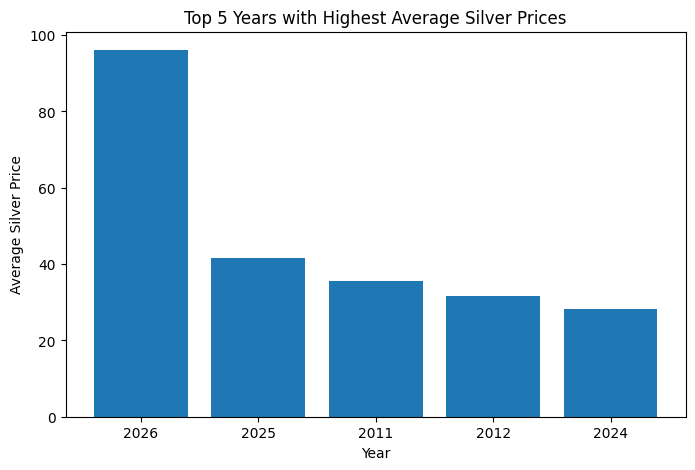

In [5]:
top5_silver = silver_avg.sort_values(
    by='Average_Silver',
    ascending=False
).head(5)

top5_silver = top5_silver.reset_index(drop=True)

display(top5_silver)

plt.figure(figsize=(8,5))
plt.bar(top5_silver['Year'].astype(str), top5_silver['Average_Silver'])
plt.title('Top 5 Years with Highest Average Silver Prices')
plt.xlabel('Year')
plt.ylabel('Average Silver Price')
plt.show()

### Interpretation

The analysis identified the five years with the highest average Silver prices in the dataset. The highest average Silver price was recorded in 2026, followed by 2025, 2011, 2012 and 2024. These results indicate that Silver prices experienced significant growth in recent years, especially during 2025 and 2026.

---

## C16. Create One Combined Chart Showing Gold and Silver Trends

This analysis compares the historical price trends of Gold and Silver using a combined line chart. By plotting both commodities on the same graph, it is possible to identify similarities, differences and overall market behaviour over time.

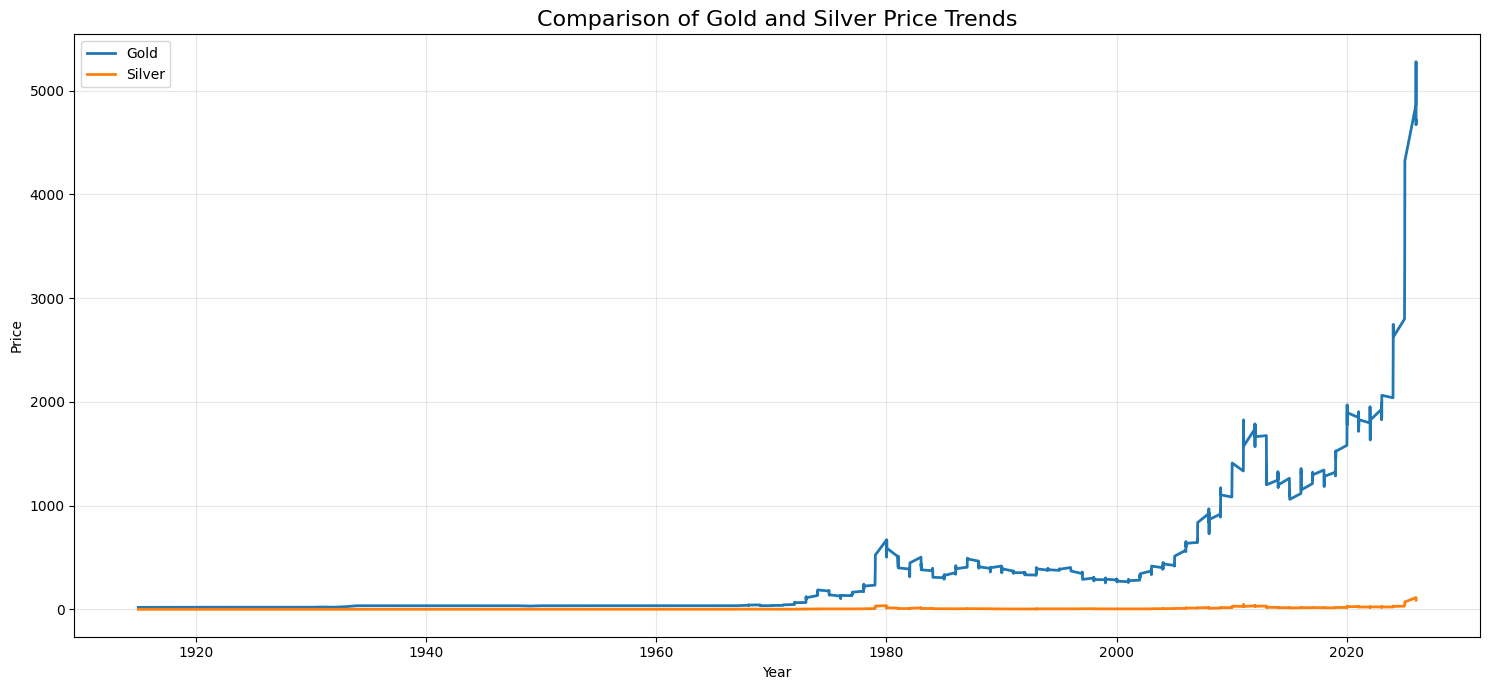

In [6]:
plt.figure(figsize=(15,7))

plt.plot(
    gold['Date'],
    gold['Value'],
    linewidth=2,
    label='Gold'
)

plt.plot(
    silver['Date'],
    silver['Value'],
    linewidth=2,
    label='Silver'
)

plt.title(
    'Comparison of Gold and Silver Price Trends',
    fontsize=16
)

plt.xlabel('Year')
plt.ylabel('Price')

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

### Interpretation

The combined chart shows that Gold and Silver generally follow similar long-term market movements. Gold exhibits a smoother upward trend, while Silver experiences larger fluctuations and sharper peaks. The greater volatility in Silver may be attributed to its dual role as both an investment asset and an industrial commodity. Overall, both commodities demonstrate long-term growth, although Silver displays more pronounced price swings than Gold.

---

## E27. Which Commodity Appears to Have the Largest Visible Price Swings?

This analysis compares Brent Oil, Gold and Silver using their minimum prices, maximum prices and overall price ranges. The price range is calculated as the difference between the maximum and minimum observed values.

,Commodity,Minimum Price,Maximum Price,Price Range
0,Brent Oil,21.11,211.2100,190.1000
1,Gold,19.25,5277.8900,5258.6400
2,Silver,0.28,113.9528,113.6728


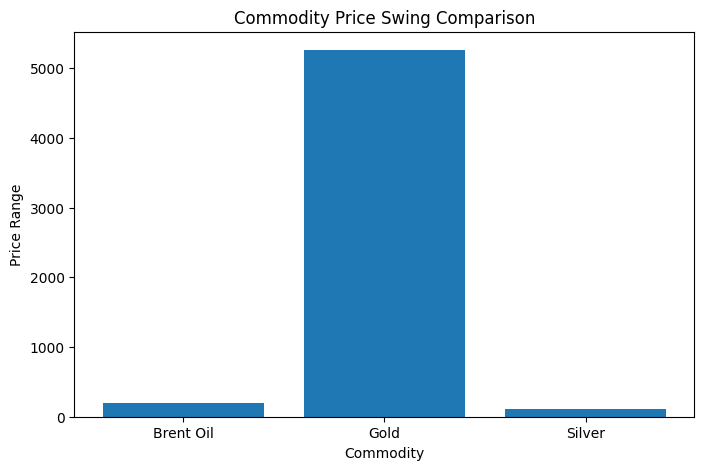

,Commodity,Minimum Price,Maximum Price,Price Range
1,Gold,19.25,5277.8900,5258.6400
0,Brent Oil,21.11,211.2100,190.1000
2,Silver,0.28,113.9528,113.6728


In [7]:
comparison = pd.DataFrame({
    'Commodity':['Brent Oil','Gold','Silver'],
    'Minimum Price':[
        brent['Value'].min(),
        gold['Value'].min(),
        silver['Value'].min()
    ],
    'Maximum Price':[
        brent['Value'].max(),
        gold['Value'].max(),
        silver['Value'].max()
    ]
})

comparison['Price Range'] = (
    comparison['Maximum Price']
    - comparison['Minimum Price']
)

display(comparison)

plt.figure(figsize=(8,5))

plt.bar(
    comparison['Commodity'],
    comparison['Price Range']
)

plt.title('Commodity Price Swing Comparison')
plt.xlabel('Commodity')
plt.ylabel('Price Range')

plt.show()

comparison.sort_values(
    'Price Range',
    ascending=False
)

### Interpretation

The results show that Gold has the largest absolute price range among the three commodities, with values increasing from approximately 19.25 to 5277.89. Brent Oil also exhibits substantial price fluctuations, largely influenced by supply disruptions, geopolitical tensions and changes in global demand. Silver demonstrates noticeable volatility but a smaller absolute price range compared with Gold. Based on the observed price ranges and the comparison chart, Gold appears to have the largest visible price swings in the dataset.

Although Gold has the largest absolute price range, Silver exhibits significant relative volatility when compared to its average price level, indicating that different measures of volatility may lead to different conclusions.

---

## Conclusion

This analysis examined key aspects of commodity and currency market behaviour using Brent Oil, Gold, Silver and Swift Currency Tracker datasets. The Swift dataset revealed multiple metrics related to global payments, trade finance and offshore RMB activity. Annual average prices showed long-term growth trends in commodities, particularly Gold. The comparison of Gold and Silver demonstrated similar long-term movements but differing levels of volatility. Finally, Gold exhibited the largest absolute price range among the analysed commodities. These findings provide useful insights into commodity market dynamics and international financial activity.

In [8]:
metric_table.to_csv('a5_metrics_table.csv', index=False)

annual_average.to_csv('annual_average_prices.csv', index=False)

top5_silver.to_csv('top5_silver_years.csv', index=False)

comparison.to_csv('commodity_price_ranges.csv', index=False)

print("CSV files saved successfully!")

CSV files saved successfully!


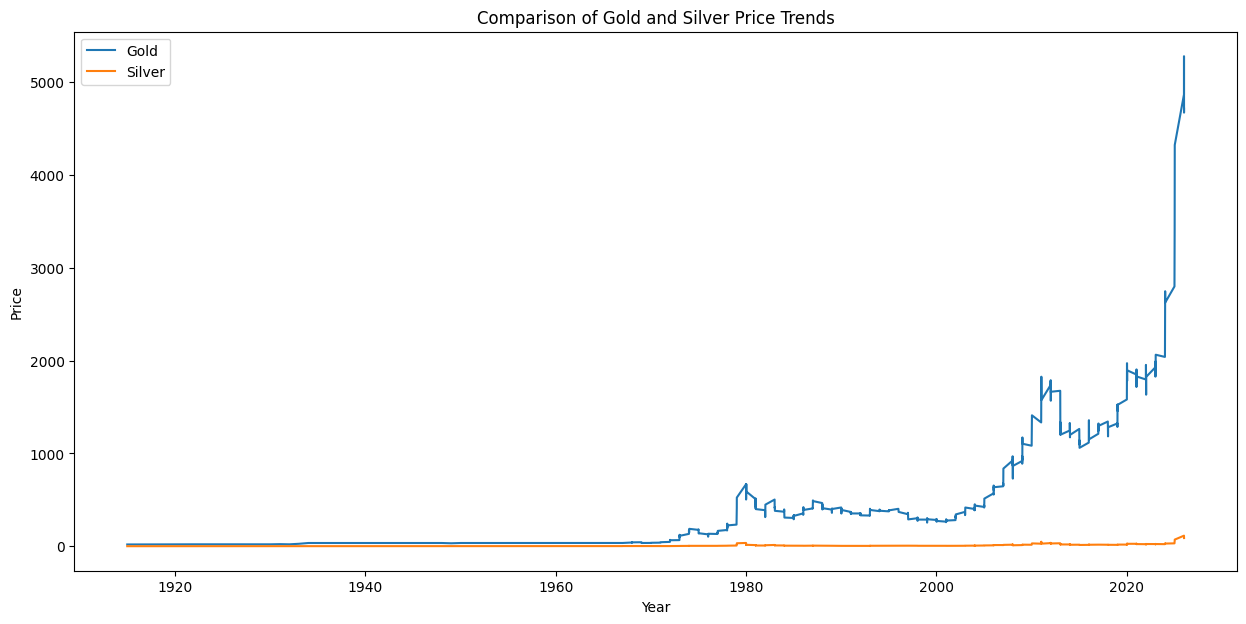

In [9]:
plt.figure(figsize=(15,7))

plt.plot(gold['Date'], gold['Value'], label='Gold')
plt.plot(silver['Date'], silver['Value'], label='Silver')

plt.title('Comparison of Gold and Silver Price Trends')
plt.xlabel('Year')
plt.ylabel('Price')
plt.legend()

plt.savefig('gold_silver_trend.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

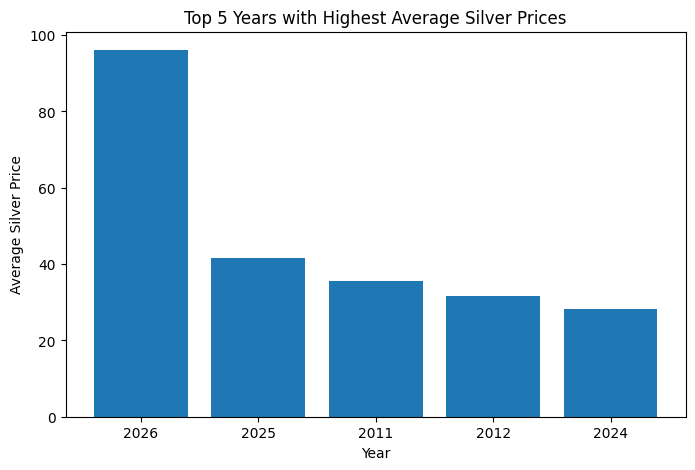

In [10]:
plt.figure(figsize=(8,5))

plt.bar(
    top5_silver['Year'].astype(str),
    top5_silver['Average_Silver']
)

plt.title('Top 5 Years with Highest Average Silver Prices')
plt.xlabel('Year')
plt.ylabel('Average Silver Price')

plt.savefig('silver_top5_years.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

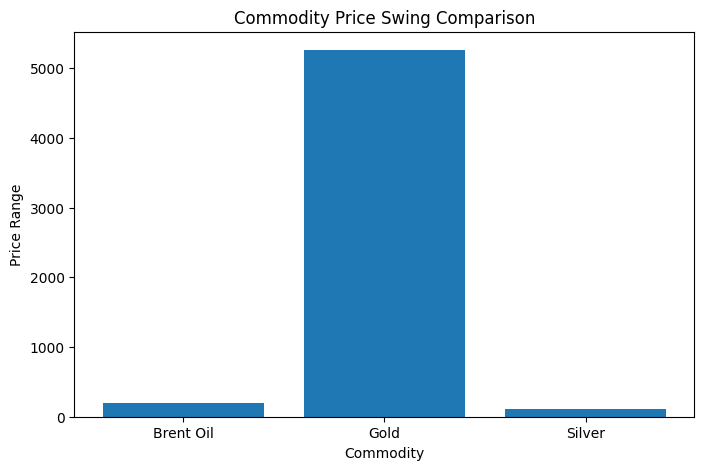

In [11]:
plt.figure(figsize=(8,5))

plt.bar(
    comparison['Commodity'],
    comparison['Price Range']
)

plt.title('Commodity Price Swing Comparison')
plt.xlabel('Commodity')
plt.ylabel('Price Range')

plt.savefig('commodity_price_swings.png',
            bbox_inches='tight',
            dpi=300)

plt.show()

# Part II: Market Research Findings

## A4. Which Event Seems Most Directly Connected to Gold or Silver Prices?

This analysis investigates which global event appears to have the strongest connection with Gold and Silver prices. The findings are linked to the combined Gold and Silver trend chart created in Part I (Question C16). Global events such as geopolitical conflicts, sanctions, inflation concerns and central bank gold accumulation can significantly influence precious metal markets.

### Analysis

The Russia-Ukraine conflict appears to be the global event most directly connected to Gold and Silver price movements. Following the outbreak of the war in 2022, financial markets experienced increased uncertainty, higher energy prices and concerns regarding inflation and economic stability. During such periods, investors often move capital towards safe-haven assets such as Gold. The Gold and Silver trend chart from Question C16 shows continued increases in precious metal prices during this period. Silver also increased, although its movements were influenced by both investment demand and industrial demand. Therefore, geopolitical conflict and the resulting economic uncertainty appear to have contributed significantly to the observed price movements in Gold and Silver.

Reference: Combined Gold and Silver Trend Chart (Question C16).

## B6. Why Might Gold Increase During Geopolitical Uncertainty?

This analysis explains why Gold prices often increase during periods of geopolitical uncertainty and links the discussion to the Gold trend identified in Part I. Gold is widely regarded as a safe-haven asset and is commonly used by investors to preserve value during periods of market instability.

### Analysis

Gold prices often increase during geopolitical uncertainty because investors seek assets that are perceived to retain value during periods of crisis. Events such as wars, sanctions, trade disputes and financial instability increase market risk and reduce investor confidence in traditional financial assets. As a result, demand for Gold typically rises. The Gold trend chart developed in Question C16 demonstrates a strong long-term upward movement and periods of price acceleration that coincide with major global uncertainties. The Russia-Ukraine conflict, inflation concerns and increased central bank Gold purchases contributed to higher demand for Gold as a store of value and portfolio hedge. Consequently, Gold acts as an important safe-haven asset during periods of geopolitical and economic uncertainty.

Reference: Combined Gold and Silver Trend Chart (Question C16).

# Final Recommendations

## Recommendations

1. Maintain portfolio diversification by including safe-haven assets such as Gold. The analysis showed that Gold demonstrated strong long-term growth and increased demand during periods of geopolitical uncertainty and economic instability.

2. Monitor commodity price volatility when making business decisions. Brent Oil and Silver exhibited significant price fluctuations that can affect production costs, transportation expenses and investment returns. Companies should adopt appropriate risk management and hedging strategies.

3. Track global currency developments and changes in international payment systems. The growing role of RMB/CNY and changes in global payment shares may influence international trade and financial planning. Businesses and policymakers should remain informed about these developments to make better strategic decisions.

## Business Conclusion

The analysis indicates that global events such as geopolitical conflicts, supply disruptions and economic uncertainty have a significant impact on commodity and currency markets. Gold displayed strong safe-haven characteristics, while Brent Oil and Silver experienced considerable volatility. Therefore, investors and businesses should adopt diversified investment strategies, monitor market risks continuously and remain informed about global economic developments when making financial decisions.